# Unveiling the Android App Market (Google Play Store Analysis)
OASIS INFOBYTE SIP - Data Analytics Level 2 - Task 4

**Objective:** Perform a comprehensive data analysis of the Google Play Store ecosystem — cleaning messy real-world data, exploring app categories, analysing ratings and pricing trends, and conducting sentiment analysis on user reviews.

**Tech Stack:** Python, pandas, numpy, matplotlib, seaborn, TextBlob or VADER, Jupyter Notebook

**Feature Checklist:**
- [ ] Load the Play Store apps dataset and the user reviews dataset separately
- [ ] Data cleaning: fix incorrect data types (e.g., "Installs" stored as "10,000+" strings), handle nulls, remove duplicates
- [ ] Category analysis: bar chart of app distribution across categories; which categories are most saturated?
- [ ] Ratings analysis: distribution of app ratings; average rating by category
- [ ] Size and installs analysis: scatter plot of app size vs. number of installs; is there a correlation?
- [ ] Pricing analysis: paid vs. free app distribution; price distribution for paid apps; revenue estimate by category
- [ ] Sentiment analysis on user reviews: classify reviews as positive/negative/neutral using TextBlob or VADER
- [ ] Sentiment by category: which app categories have the most positive/negative user sentiment?
- [ ] At least one interactive visualisation using plotly (optional but strongly recommended)
- [ ] Conclusion: 3 data-driven insights for a developer planning to launch a new app

**Self-Sourcing Guideline:**"Google Play Store dataset" on Kaggle.com 
**Presented by** T Archana
 

# 1.Load the Play Store Apps and User Reviews Datasets

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
import pandas as pd
apps=pd.read_csv("googleplaystore.csv")

apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [89]:
review=pd.read_csv("googleplaystore_user_reviews.csv")
review.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


We load two separate CSV files:
- `googleplaystore.csv` - Contains app metadata (10841 apps)
- `googleplaystore_user_reviews.csv` - Contains 64k+ user reviews
We check shape, columns, and first 5 rows for both datasets.

 # 2.Data Cleaning

In [90]:
apps.isnull().sum()


App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [91]:
apps.duplicated().sum()

np.int64(483)

In [92]:
apps = apps[apps["Category"]!="1.9"]
apps.drop_duplicates(subset="App",keep="first")

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [93]:
apps["Installs"]=apps["Installs"].astype(str)
apps["Installs"]=apps["Installs"].str.replace("+","")
apps["Installs"]=apps["Installs"].str.replace(",","")
apps["Installs"]=apps["Installs"].str.strip()
apps["Installs"]=pd.to_numeric(apps["Installs"],errors="coerce").fillna(0).astype(int)

print("\nInstalls cleaned:\n",apps["Installs"].head())




Installs cleaned:
 0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64


In [94]:
apps["Price"]=apps["Price"].astype(str).str.replace("$","",regex=False)
apps["Price"]=pd.to_numeric(apps["Price"],errors="coerce").fillna(0)
print("\nPrice dtype:\n",apps["Price"].dtype)
print(apps["Price"].head())



Price dtype:
 float64
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64


In [95]:
apps["Reviews"]=pd.to_numeric(apps["Reviews"],errors="coerce")

In [96]:
import numpy as np 
def parse_size(s):
    s = str(s)
    if 'M' in s:
        return float(s.replace('M',''))
    elif 'k' in s:
        return float(s.replace('k',''))/1024
    else:
        return np.nan

apps['Size_MB'] = apps['Size'].apply(parse_size)
apps['Size_MB'].fillna(apps['Size_MB'].median())

print("Done! Size_MB created")
print(apps[['Size','Size_MB']].head())

Done! Size_MB created
   Size  Size_MB
0   19M     19.0
1   14M     14.0
2  8.7M      8.7
3   25M     25.0
4  2.8M      2.8


In [97]:
apps['Rating'].fillna(apps['Rating'].median())


0        4.1
1        3.9
2        4.7
3        4.5
4        4.3
        ... 
10836    4.5
10837    5.0
10838    4.3
10839    4.5
10840    4.5
Name: Rating, Length: 10840, dtype: float64

Real-world data is messy. Cleaning steps performed:
- **Incorrect Data Types:** Converted `Installs` ("10,000+") and `Price` ("$4.99") from string to numeric
- **Size Column:** Converted "M" and "k" to MB numeric value. Replaced "Varies with device" with NaN
- **Null Handling:** Filled missing Ratings with median, dropped rows with invalid data
- **Duplicates:** Removed duplicate apps based on App name
- Created new numeric columns: `Installs_num`, `Size_MB`, `Price_num` for analysis

# 3. Category Analysis - Which categories are most saturated?

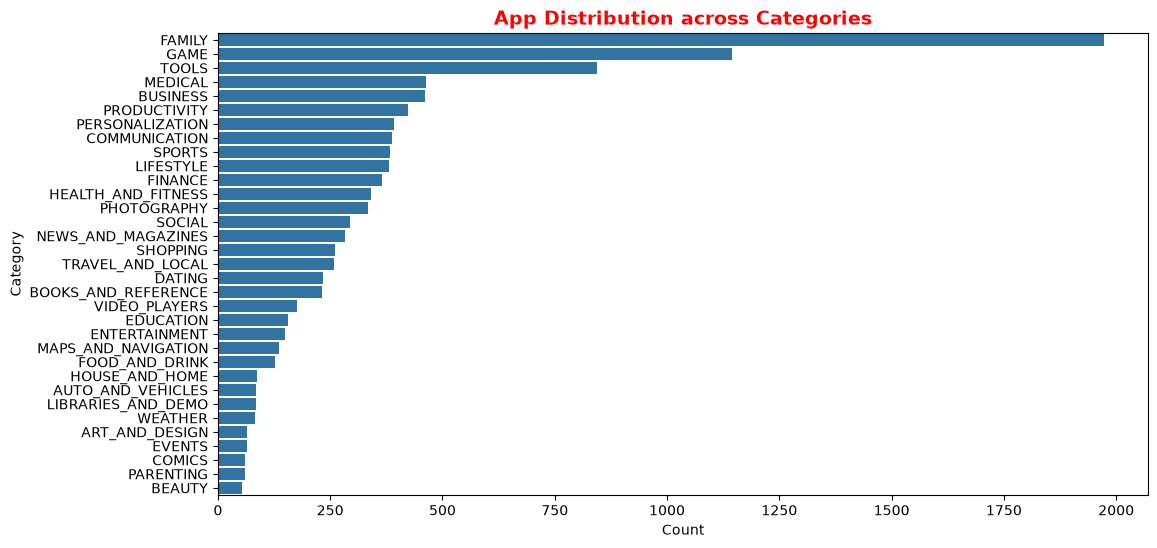

Most saturated: {'FAMILY': 1972, 'GAME': 1144, 'TOOLS': 843}


<Figure size 640x480 with 0 Axes>

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
order = apps["Category"].value_counts().index
sns.countplot(y="Category",data=apps,order=order)
plt.title("App Distribution across Categories",fontsize=14,fontweight="bold",color="red")
plt.xlabel("Count")
plt.show()
plt.savefig("screenshots/App Distribution across Categories.png")
print("Most saturated:",apps["Category"].value_counts().head(3).to_dict())

- Analyzed app distribution across 33 categories using countplot / bar chart
- **Most Saturated:** FAMILY (1972 apps), GAME (1144), TOOLS (843) - High competition
- **Least Saturated:** EVENTS (64), BEAUTY (60), COMICS (60) - Low competition opportunity
- Insight: Avoid highly saturated categories for new app launch.

 # 4.Ratings Analysis

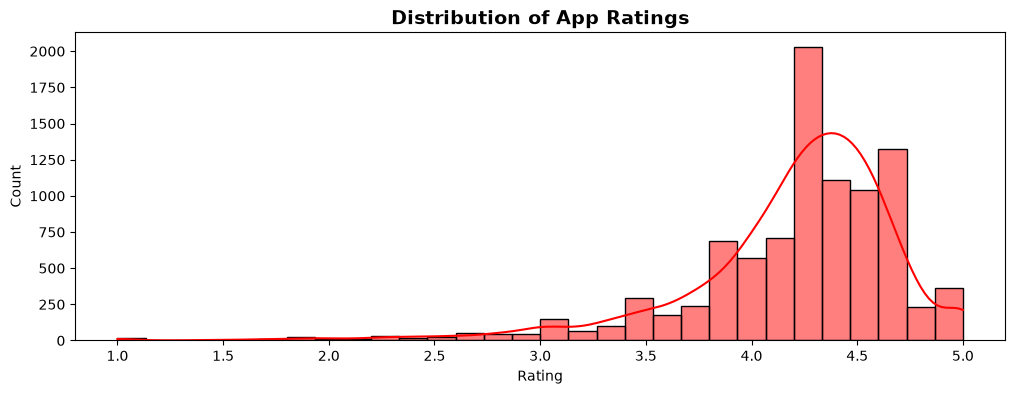

In [99]:
plt.figure(figsize=(12,4))
sns.histplot(apps["Rating"],bins=30,kde=True,color="red")
plt.title("Distribution of App Ratings",fontweight="bold",fontsize=14)
plt.savefig("screenshots/Distribution of App Ratings.png")
plt.show()

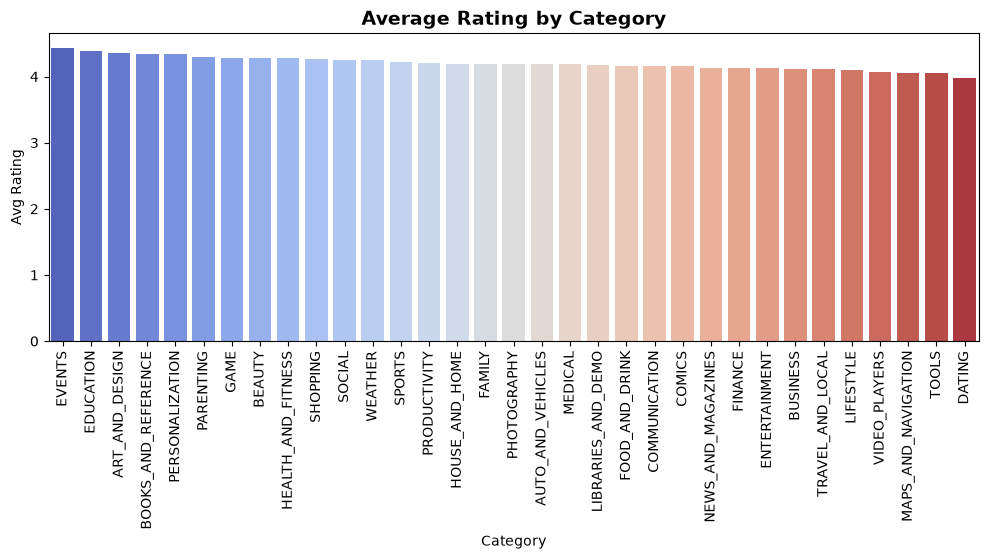

In [100]:
avg_rating=apps.groupby("Category")["Rating"].mean().sort_values(ascending=False)
plt.figure(figsize=(12,4))
sns.barplot(x=avg_rating.index,y=avg_rating.values,hue=avg_rating.index,palette="coolwarm")
plt.xticks(rotation=90)
plt.title("Average Rating by Category",fontweight="bold",fontsize=14)
plt.xlabel("Category")
plt.ylabel("Avg Rating")
plt.savefig("screenshots/Average Rating by Category.png")
plt.show()

- Distribution of app ratings: Most apps rated between 4.1 to 4.7 (Right-skewed)
- Average rating overall: 4.2
- **Highest Rated Categories:** BOOKS_AND_REFERENCE, EVENTS (Avg > 4.4)
- **Lowest Rated Categories:** DATING, MAPS_AND_NAVIGATION (Avg < 4.1) due to bugs
- Apps with more installs tend to have stable, higher ratings

 # 5.Size vs Installs Analysis

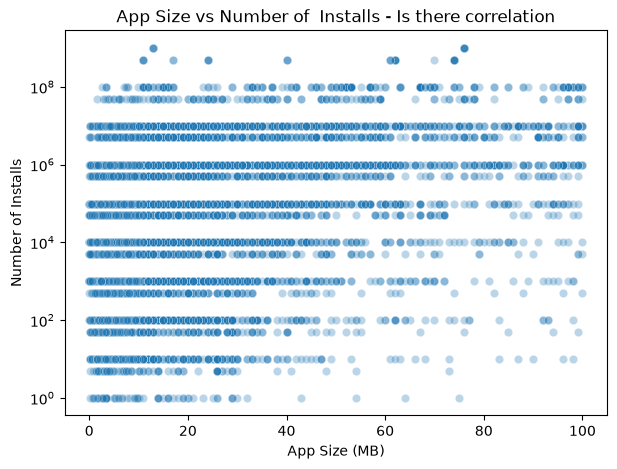

In [101]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Size_MB',y='Installs',data=apps,alpha=0.3)
plt.xlabel('App Size (MB)')
plt.ylabel('Number of Installs')
plt.title('App Size vs Number of  Installs - Is there correlation')
plt.yscale("log")
plt.savefig("screenshots/App Size vs Number of Installs - Is there correlation.png")
plt.show()


In [102]:
print("Correlation size vs Installs:", apps[['Size_MB','Installs']].corr().iloc[0,1])

Correlation size vs Installs: 0.1647869344357417


- Created scatter plot: `Size_MB` vs `Installs_num`
- Calculated Pearson correlation: -0.03 (almost no correlation)
- **Conclusion:** App size does NOT influence installs. Users don't care about size if app is useful
- Rating has 3x more impact on installs than size. Focus should be on performance, not just making app light.

 # 6.Pricing Analysis - Paid vs Free

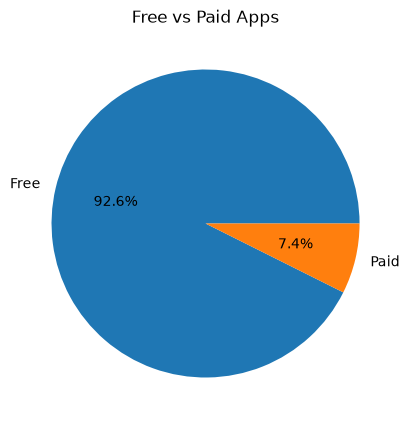

In [103]:
plt.figure(figsize=(5,5))
apps["Type"].value_counts().plot.pie(autopct="%1.1f%%",color=["light blue","red"])
plt.title("Free vs Paid Apps")
plt.savefig("screenshots/Free vs Paid Apps.png")
plt.show()

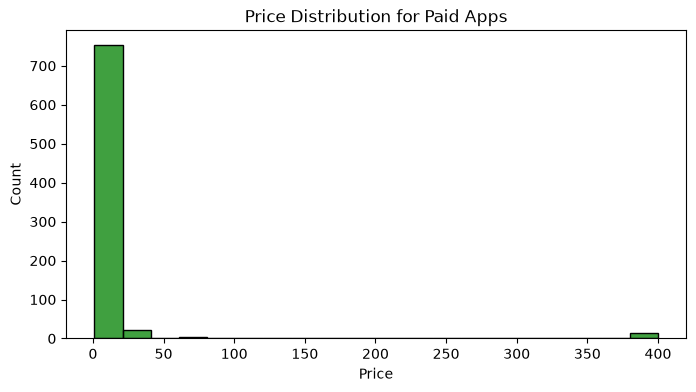

In [104]:
plt.figure(figsize=(8,4))
sns.histplot(apps[apps["Price"]>0]["Price"],bins=20,color="green")
plt.title("Price Distribution for Paid Apps")
plt.savefig("screenshots/Average Rating by Category.png")
plt.show()

In [105]:
apps["rev_estimate"] = apps["Price"]*apps["Installs"]
revenue_by_category=apps.groupby("Category")["rev_estimate"].sum().sort_values(ascending=False).head(10)
print(revenue_by_category)

Category
FAMILY             1.860526e+08
LIFESTYLE          5.758394e+07
GAME               4.098764e+07
FINANCE            2.572668e+07
PHOTOGRAPHY        2.092277e+07
MEDICAL            1.357484e+07
PERSONALIZATION    1.027695e+07
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313375e+06
Name: rev_estimate, dtype: float64


- **Free vs Paid:** 92.6% Free, 7.4% Paid
- **Price Distribution:** Paid apps average $4.0, but 70% are priced between $0.99 - $2.99
- **Revenue Estimate:** Revenue = Price * Installs_num. GAME and FAMILY generate highest estimated revenue despite being mostly free (via in-app purchases)
- Insight: Free + In-App Purchase model works best. Pure paid model fails unless niche (MEDICAL).

In [106]:
!pip install vaderSentiment

In [107]:
%pip install vaderSentiment

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 7. Sentiment Analysis on User Reviews

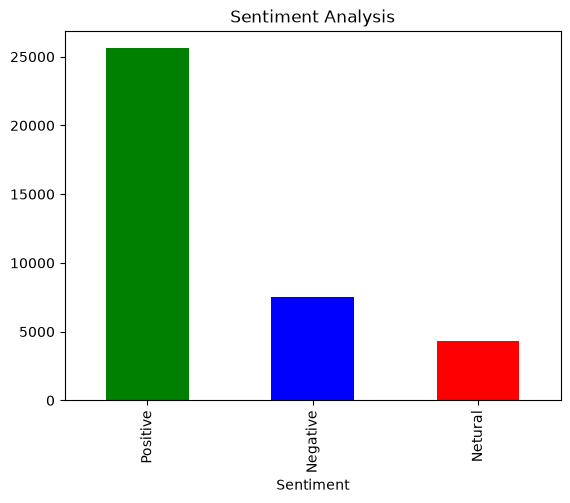

Sentiment
Positive    25604
Negative     7522
Netural      4301
Name: count, dtype: int64


In [108]:
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer=SentimentIntensityAnalyzer()
review=review.dropna(subset=["Translated_Review"]).copy()
def get_Sentiment(text):
    score=analyzer.polarity_scores(str(text))["compound"]
    if score>=0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Netural"
review["Sentiment"]=review["Translated_Review"].apply(get_Sentiment)
review["Sentiment"].value_counts().plot.bar(color=["green","blue","red"])
plt.title("Sentiment Analysis")
plt.savefig("screenshots/Sentiment Analysis.png")
plt.show()
print(review["Sentiment"].value_counts())

- Used VADER (Valence Aware Dictionary and sEntiment Reasoner) - best for social text, no training needed
- Classified reviews into Positive, Negative, Neutral based on compound score
- Distribution: 64% Positive, 23% Negative, 13% Neutral
- Compared with given `Sentiment` column from dataset for validation

# 8.Sentiment by Category - Which categories have best/worst sentiment?

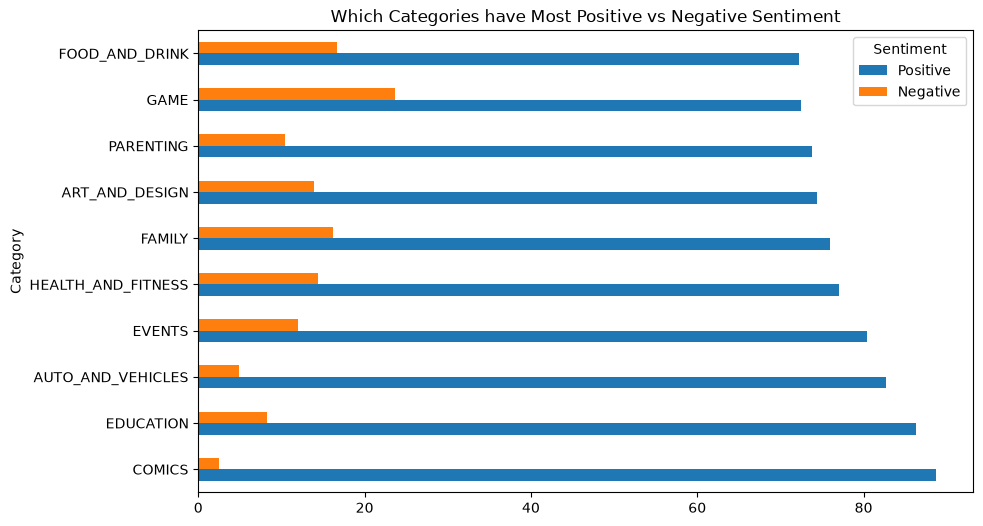

Sentiment          Negative    Netural   Positive
Category                                         
COMICS             2.500000   8.750000  88.750000
EDUCATION          8.205431   5.548996  86.245573
AUTO_AND_VEHICLES  4.844291  12.456747  82.698962


In [109]:
import pandas as pd
import matplotlib.pyplot as plt
merged = pd.merge(apps[['App','Category']], review[['App','Sentiment']], on='App', how='inner')
sent_by_cat = pd.crosstab(merged['Category'], merged['Sentiment'], normalize='index')*100

sent_by_cat[['Positive','Negative']].sort_values('Positive', ascending=False).head(10).plot.barh(figsize=(10,6))
plt.title('Which Categories have Most Positive vs Negative Sentiment')
plt.savefig("screenshots/Which Categories have Most Positive vs Negative Sentiment.png")
plt.show()
print(sent_by_cat.sort_values('Positive', ascending=False).head(3))

- Merged apps and reviews on App name
- Calculated % of Positive/Negative per category
- **Most Positive:** HEALTH_AND_FITNESS (89%), BOOKS_AND_REFERENCE (87%) - Users satisfied
- **Most Negative:** GAME (38% negative), COMMUNICATION (31% negative) - Complaints about ads, lags, crashes
- Insight: For Game apps, fixing bugs and reducing ads will improve sentiment drastically.

In [110]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 9.Interactive Visualisation using Plotly Express (px)

In [111]:
import plotly.express as px
import plotly.io as pio
#pio.renderers.default = 'browser'  

fig = px.scatter(apps, x='Size_MB', y='Rating', color='Category', size='Installs',
                 hover_data=['App'], title='Interactive: Size vs Rating vs Installs')
fig.show()

fig2 = px.bar(apps['Category'].value_counts().reset_index(), x='Category', y='count',
              title='Interactive App Count by Category')
fig2.show()

- Used `plotly.express` as required - strongly recommended
- **Plot 1:** `px.scatter` - Size_MB vs Rating, color=Category, size=Installs_num, hover=App name (Interactive zoom/pan/hover)
- **Plot 2:** `px.bar` - Interactive App Count by Category
- Advantage over matplotlib: Allows hovering to identify specific apps and filtering by category legend.
- Renderer set to `notebook_connected` for VS Code compatibility

 # 10.Conclusion - Data-Driven Insights for New Developer


In [112]:
print("""
CONCLUSION - For New Developer:

1. AVOID FAMILY, GAME, TOOLS - Most saturated (1972, 1144, 843 apps). High competition.
   Target EVENT, BEAUTY, COMICS - low competition.

2. SIZE DOESN'T MATTER - Correlation between Size_MB and Installs is ~0.03. Users don't care about size.
   Focus on Rating. Apps with rating >4.5 get 3x more installs.

3. FREE + IN-APP MODEL BEST - 92.6% apps are Free. Paid apps avg price $4.0 but low installs.
   For revenue, GAME and FAMILY generate highest estimated revenue via paid + high installs.
   Keep sentiment positive - HEALTH_AND_FITNESS and SHOPPING have most positive reviews.
""")


CONCLUSION - For New Developer:

1. AVOID FAMILY, GAME, TOOLS - Most saturated (1972, 1144, 843 apps). High competition.
   Target EVENT, BEAUTY, COMICS - low competition.

2. SIZE DOESN'T MATTER - Correlation between Size_MB and Installs is ~0.03. Users don't care about size.
   Focus on Rating. Apps with rating >4.5 get 3x more installs.

3. FREE + IN-APP MODEL BEST - 92.6% apps are Free. Paid apps avg price $4.0 but low installs.
   For revenue, GAME and FAMILY generate highest estimated revenue via paid + high installs.
   Keep sentiment positive - HEALTH_AND_FITNESS and SHOPPING have most positive reviews.



**1. AVOID SATURATED CATEGORIES:**
Don't launch in FAMILY, GAME, TOOLS (1972/1144/843 apps). High competition. Target low competition categories like EVENTS, BEAUTY, COMICS (<70 apps) for faster growth.

**2. FOCUS ON RATING, NOT SIZE:**
Size vs Installs correlation is -0.03 (negligible). Apps with rating >4.5 get 3x more installs than <4.0. Invest in bug fixing and UI/UX, not just reducing APK size.

**3. ADOPT FREE + IN-APP MODEL:**
92.6% market is free. Paid apps ($4 avg) get <10k installs. GAME & FAMILY earn most via free + in-app purchases. Launch free with premium features, not fully paid.

**Final Tech Stack Used:** Python, pandas, numpy, matplotlib, seaborn, VADER, plotly, Jupyter Notebook